#Import Libraries

In [0]:
!pip install datasets

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from datasets import load_dataset
from pandas import Series, DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
sns.set_style('whitegrid')
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from io import StringIO

#About the Training Data

In [0]:
#Load Dataset

df = load_dataset("json", data_files="file:///dbfs/FileStore/shared_uploads/mhuy@smu.edu/train.json")
train = df["train"]

In [0]:
#Training Info and Decription

telecom = train.to_pandas()
telecom.info()
telecom.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  2400 non-null   object
 1   answer    2400 non-null   object
dtypes: object(2)
memory usage: 37.6+ KB


question answer
count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [0]:
#Inspect Row 1- Text Output

pd.set_option('display.max_colwidth', None)
telecom.head(1)

question answer
0  Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average scheduled RBs are below 160, affecting throughput.\n\nGiven:\n- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the actual downtilt angle in degrees.\n\nBeam Scenario and Vertical Beamwidth Relationships:\n- When the cell's Beam Scenario is set to Default or SCENARIO_1 to SCENARIO_5, the vertical beamwidth is 6 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_6 to SCENARIO_11, the vertical beamwidth is 12 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_12 or above, the vertical beamwidth is 25 degrees.\n\nUser plane drive test data as follows：\n\nTimestamp|Longitude|Latitude|GPS Speed (km/h)|5G KPI PCell RF Serving PCI|5G KPI PCell RF Serving SS-RSRP [dBm]|5G KPI PCell RF Serving SS-SINR [dB]|5G KPI PCell Layer2 MAC DL Throughput [Mbps]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]|5G KPI PCell Layer1 DL RB Num (Including 0)\n2025-05-07 15:23:52.000000|128.188169|32.579273|1|712|-77.0|15.93|1351.25|258|71|284|-|-|-90.49|-95.82|-102.2|-|-|210.91\n2025-05-07 15:23:53.000000|128.18814|32.579223|2|71|-80.97|6.6|366.57|258|712|129|-|-|-88.72|-93.26|-105.47|-|-|211.23\n2025-05-07 15:23:54.000000|128.188117|32.579174|16|71|-85.5|1.81|334.0|258|712|-|-|-|-84.41|-96.46|-|-|-|210.99\n2025-05-07 15:23:55.000000|128.188103|32.579113|14|71|-88.21|5.4|431.94|712|258|-|-|-|-88.04|-93.72|-|-|-|195.26\n2025-05-07 15:23:56.000000|128.188088|32.579075|19|71|-78.45|13.59|566.34|712|258|284|-|-|-87.97|-98.7|-105.92|-|-|209.0\n2025-05-07 15:23:57.000000|128.188073|32.579033|22|258|-77.45|11.45|1308.74|712|71|284|129|-|-89.56|-93.31|-104.18|-110.78|-|204.95\n2025-05-07 15:23:58.000000|128.188051|32.579002|16|258|-81.66|10.06|1310.14|712|71|284|129|-|-84.85|-93.3|-102.87|-114.09|-|210.13\n2025-05-07 15:23:59.000000|128.188073|32.578995|26|258|-79.13|16.32|1023.36|712|71|284|129|-|-86.75|-93.71|-104.01|-107.26|-|208.06\n2025-05-07 15:24:00.000000|128.188036|32.578984|33|258|-74.09|19.8|770.83|712|71|284|129|-|-89.29|-96.4|-100.21|-114.11|-|207.07\n2025-05-07 15:24:01.000000|128.188036|32.578984|25|258|-71.09|19.62|1014.75|712|71|-|-|-|-90.14|-92.93|-|-|-|205.57\n\n\nEngeneering parameters data as follows：\n\ngNodeB ID|Cell ID|Longitude|Latitude|Mechanical Azimuth|Mechanical Downtilt|Digital Tilt|Digital Azimuth|Beam Scenario|Height|PCI|TxRx Mode|Max Transmit Power|Antenna Model\n0034038|4|128.188273|32.579129|50|6|4|0|DEFAULT|5.0|712|64T64R|34.9|NR AAU 2\n0033164|27|12

#Clean Training Data

In [0]:
#Missing Data
telecom.isnull().sum()

question    0
answer      0
dtype: int64

In [0]:
#Duplicates
telecom.duplicated().sum()

np.int64(0)

In [0]:
#Split Text Column
split_cols = telecom['question'].str.split('|', expand=True)

#Show Row 1
split_cols.head(1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393
0,"Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average scheduled RBs are below 160, affecting throughput.\n\nGiven:\n- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the actual downtilt angle in degrees.\n\nBeam Scenario and Vertical Beamwidth Relationships:\n- When the cell's Beam Scenario is set to Default or SCENARIO_1 to SCENARIO_5, the vertical beamwidth is 6 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_6 to SCENARIO_11, the vertical beamwidth is 12 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_12 or above, the vertical beamwidth is 25 degrees.\n\nUser plane drive test data as follows：\n\nTimestamp",Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)\n2025-05-07 15:23:52.000000,128.188169,32.579273,1,712,-77.0,15.93,1351.25,258,71,284,-,-,-90.49,-95.82,-102.2,-,-,210.91\n2025-05-07 15:23:53.000000,128.18814,32.579223,2,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


#Inspect Complete Rows

In [0]:
#Complete Rows
row_missing = split_cols.isna().sum(axis=1)
complete_rows = row_missing[row_missing == 0]

print(f"Number of complete rows: {len(complete_rows)}")
print(complete_rows.index.tolist())

Number of complete rows: 4
[334, 377, 1490, 1609]


In [0]:
#Display Complete Rows
split_cols.loc[[334, 377, 1490, 1609]]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393
334,"Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average scheduled RBs are below 160, affecting throughput.\n\nGiven:\n- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the actual downtilt angle in degrees.\n\nBeam Scenario and Vertical Beamwidth Relationships:\n- When the cell's Beam Scenario is set to Default or SCENARIO_1 to SCENARIO_5, the vertical beamwidth is 6 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_6 to SCENARIO_11, the vertical beamwidth is 12 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_12 or above, the vertical beamwidth is 25 degrees.\n\nUser plane drive test data as follows：\n\nTimestamp",Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)\n2025-05-07 13:30:32.000000,128.192162,32.585255,13,400,-83.0,6.3,877.44,696,333,9,193,151,-87.44,-96.43,-101.76,-103.06,-112.82,208.68\n2025-05-07 13:30:33.000000,128.192098,32.585226,21,...,NR AAU 2\n0033237,15,128.190584,32.586622,170,1,12,0,DEFAULT,25.5,333,32T32R,34.9,NR AAU 1\n0033237,24,128.189391,32.58595,330,19,6,0,SCENARIO_3,81.0,502,64T64R,34.9,NR AAU 2\n0033978,28,128.194223,32.591983,260,20,6,0,DEFAULT,61.0,563,32T32R,34.9,NR AAU 3\n
377,"Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average 

#Create Drive Test and Engineering Sections

In [0]:
# Split drive-test and engineering sections
def parse_question(question):   
    drive_part = question.split("User plane drive test data as follows：")[1]
    drive_table_text = drive_part.split("Engeneering parameters data as follows：")[0].strip()

    eng_table_text = question.split("Engeneering parameters data as follows：")[1].strip()

    # Convert into dataframes
    drive_df = pd.read_csv(StringIO(drive_table_text), sep="|")
    engineering_df = pd.read_csv(StringIO(eng_table_text), sep="|")

    return drive_df, engineering_df

#Row 334

In [0]:
#Drive Test
drive_df, engineering_df = parse_question(telecom.loc[334, "question"])

display(drive_df)
display(engineering_df)

Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
2025-05-07 13:30:32.000000,128.192162,32.585255,13,400,-83.0,6.3,877.44,696,333,9,193,151,-87.44,-96.43,-101.76,-103.06,-112.82,208.68
2025-05-07 13:30:33.000000,128.192098,32.585226,21,400,-86.6,1.04,72.13,696,333,868,498,656,-84.3,-88.94,-100.08,-107.04,-111.63,209.12
2025-05-07 13:30:34.000000,128.192033,32.585208,3,696,-83.13,-2.45,46.45,400,333,-,-,-,-83.53,-91.45,-,-,-,208.62
2025-05-07 13:30:35.000000,128.191968,32.585196,5,400,-88.88,3.33,120.82,696,333,498,596,656,-79.94,-92.2,-98.64,-105.65,-105.03,183.66
2025-05-07 13:30:36.000000,128.191904,32.585197,21,696,-75.01,10.22,243.25,400,333,-,-,-,-85.85,-91.31,-,-,-,200.3
2025-05-07 13:30:37.000000,128.191831,32.585197,38,696,-78.0,12.19,1121.33,400,333,-,-,-,-79.5,-94.1,-,-,-,203.36
2025-05-07 13:30:38.000000,128.191782,32.58521,20,696,-70.33,12.28,1095.42,400,333,-,-,-,-81.92,-88.07,-,-,-,209.21
2025-05-07 13:30:39.000000,128.19166,32.585241,7,696,-69.26,11.6,1115.75,400,333,767,563,-,-82.04,-89.16,-96.37,-99.54,-,202.02
2025-05-07 13:30:40.000000,128.191618,32.585245,12,696,-71.9,10.24,1043.76,400,333,193,-,-,-85.63,-93.47,-94.91,-,-,181.96
2025-05-07 13:30:41.000000,128.191581,32.58525,17,696,-75.07,9.71,1135.43,400,333,767,-,-,-85.55,-91.65,-95.53,-,-,205.23


gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
33918,28,128.19357,32.584483,290,5,9,0,SCENARIO_8,42.7,400,32T32R,34.9,NR AAU 1
293,0,128.17586,32.589458,192,9,7,0,SCENARIO_9,3.0,660,64T64R,34.9,NR AAU 2
33237,4,128.188201,32.585896,110,1,10,0,SCENARIO_3,18.6,596,32T32R,34.9,NR AAU 3
34039,24,128.191964,32.574255,0,0,255,0,DEFAULT,0.0,9,2T2R,46.0,Other
33164,2,128.18706,32.585968,340,6,9,0,SCENARIO_3,51.1,193,32T32R,34.9,NR AAU 3
33164,12,128.190094,32.583492,45,6,4,0,DEFAULT,22.0,151,64T64R,34.9,NR AAU 2
34036,14,128.200705,32.594691,0,0,255,0,EXPAND_SCENARIO_2,0.0,868,4T4R,46.0,Other
34039,3,128.191982,32.57877,290,39,255,0,DEFAULT,123.0,498,64T64R,34.9,NR AAU 2
34039,4,128.192438,32.578746,255,20,255,0,DEFAULT,111.0,656,64T64R,34.9,NR AAU 2
33918,52,128.192061,32.582535,110,3,11,0,DEFAULT,18.6,696,32T32R,34.9,NR AAU 1


In [0]:
#Engineering Table
telecom_structured = telecom[["question", "answer"]].copy()

parsed_tables = telecom_structured["question"].apply(parse_question)

telecom_structured["drive_test"] = parsed_tables.apply(lambda x: x[0])
telecom_structured["engineering"] = parsed_tables.apply(lambda x: x[1])

display(telecom_structured.loc[0, "drive_test"])
display(telecom_structured.loc[0, "engineering"])

Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
2025-05-07 15:23:52.000000,128.188169,32.579273,1,712,-77.0,15.93,1351.25,258,71,284,-,-,-90.49,-95.82,-102.2,-,-,210.91
2025-05-07 15:23:53.000000,128.18814,32.579223,2,71,-80.97,6.6,366.57,258,712,129,-,-,-88.72,-93.26,-105.47,-,-,211.23
2025-05-07 15:23:54.000000,128.188117,32.579174,16,71,-85.5,1.81,334.0,258,712,-,-,-,-84.41,-96.46,-,-,-,210.99
2025-05-07 15:23:55.000000,128.188103,32.579113,14,71,-88.21,5.4,431.94,712,258,-,-,-,-88.04,-93.72,-,-,-,195.26
2025-05-07 15:23:56.000000,128.188088,32.579075,19,71,-78.45,13.59,566.34,712,258,284,-,-,-87.97,-98.7,-105.92,-,-,209.0
2025-05-07 15:23:57.000000,128.188073,32.579033,22,258,-77.45,11.45,1308.74,712,71,284,129,-,-89.56,-93.31,-104.18,-110.78,-,204.95
2025-05-07 15:23:58.000000,128.188051,32.579002,16,258,-81.66,10.06,1310.14,712,71,284,129,-,-84.85,-93.3,-102.87,-114.09,-,210.13
2025-05-07 15:23:59.000000,128.188073,32.578995,26,258,-79.13,16.32,1023.36,712,71,284,129,-,-86.75,-93.71,-104.01,-107.26,-,208.06
2025-05-07 15:24:00.000000,128.188036,32.578984,33,258,-74.09,19.8,770.83,712,71,284,129,-,-89.29,-96.4,-100.21,-114.11,-,207.07
2025-05-07 15:24:01.000000,128.188036,32.578984,25,258,-71.09,19.62,1014.75,712,71,-,-,-,-90.14,-92.93,-,-,-,205.57


gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
34038,4,128.188273,32.579129,50,6,4,0,DEFAULT,5.0,712,64T64R,34.9,NR AAU 2
33164,27,128.217634,32.58072,240,3,10,0,DEFAULT,29.7,71,32T32R,34.9,NR AAU 1
34038,2,128.188282,32.579099,140,10,4,0,DEFAULT,5.0,258,64T64R,34.9,NR AAU 2
34038,24,128.18769,32.57791,40,44,9,10,SCENARIO_9,56.0,284,64T64R,34.9,NR AAU 2
33164,14,128.189481,32.581043,150,20,255,0,DEFAULT,28.7,129,64T64R,34.9,NR AAU 2


In [0]:
#New Telecom Table Information
telecom_structured.shape

(2400, 4)

#Show First Two Drive Test (Row 0 and Row 1)

Drive Test: What happened?

In [0]:
for i in range(2):
    print(f"ROW {i}")
    print(f"ANSWER: {telecom_structured.loc[i, 'answer']}")

    display(telecom_structured.loc[i, 'drive_test'])

ROW 0
ANSWER: C2


Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
2025-05-07 15:23:52.000000,128.188169,32.579273,1,712,-77.0,15.93,1351.25,258,71,284,-,-,-90.49,-95.82,-102.2,-,-,210.91
2025-05-07 15:23:53.000000,128.18814,32.579223,2,71,-80.97,6.6,366.57,258,712,129,-,-,-88.72,-93.26,-105.47,-,-,211.23
2025-05-07 15:23:54.000000,128.188117,32.579174,16,71,-85.5,1.81,334.0,258,712,-,-,-,-84.41,-96.46,-,-,-,210.99
2025-05-07 15:23:55.000000,128.188103,32.579113,14,71,-88.21,5.4,431.94,712,258,-,-,-,-88.04,-93.72,-,-,-,195.26
2025-05-07 15:23:56.000000,128.188088,32.579075,19,71,-78.45,13.59,566.34,712,258,284,-,-,-87.97,-98.7,-105.92,-,-,209.0
2025-05-07 15:23:57.000000,128.188073,32.579033,22,258,-77.45,11.45,1308.74,712,71,284,129,-,-89.56,-93.31,-104.18,-110.78,-,204.95
2025-05-07 15:23:58.000000,128.188051,32.579002,16,258,-81.66,10.06,1310.14,712,71,284,129,-,-84.85,-93.3,-102.87,-114.09,-,210.13
2025-05-07 15:23:59.000000,128.188073,32.578995,26,258,-79.13,16.32,1023.36,712,71,284,129,-,-86.75,-93.71,-104.01,-107.26,-,208.06
2025-05-07 15:24:00.000000,128.188036,32.578984,33,258,-74.09,19.8,770.83,712,71,284,129,-,-89.29,-96.4,-100.21,-114.11,-,207.07
2025-05-07 15:24:01.000000,128.188036,32.578984,25,258,-71.09,19.62,1014.75,712,71,-,-,-,-90.14,-92.93,-,-,-,205.57


ROW 1
ANSWER: C1


Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
2025-05-07 16:22:16.000000,128.188765,32.580933,17,71,-86.03,17.36,850.53,307,498,868,-,-,-93.31,-105.85,-116.17,-,-,210.39
2025-05-07 16:22:17.000000,128.188773,32.580926,20,71,-85.42,14.09,1202.59,307,498,868,151,-,-92.17,-100.52,-107.25,-117.89,-,210.94
2025-05-07 16:22:18.000000,128.188779,32.580914,22,71,-82.24,11.57,520.58,307,498,868,-,-,-95.62,-99.37,-107.33,-,-,211.09
2025-05-07 16:22:19.000000,128.188793,32.580895,3,71,-87.98,11.32,490.28,307,498,868,-,-,-98.66,-103.8,-108.35,-,-,210.95
2025-05-07 16:22:20.000000,128.188778,32.580865,5,307,-86.82,14.64,388.58,71,498,368,-,-,-94.4,-97.99,-107.43,-,-,210.44
2025-05-07 16:22:21.000000,128.188759,32.580476,21,307,-77.67,10.16,482.09,71,498,368,-,-,-90.76,-98.14,-103.59,-,-,210.84
2025-05-07 16:22:22.000000,128.188749,32.580766,17,307,-86.21,6.89,1170.78,71,498,368,-,-,-91.42,-97.37,-103.69,-,-,198.41
2025-05-07 16:22:23.000000,128.188719,32.580697,33,307,-80.95,7.08,1212.16,71,498,368,-,-,-93.43,-98.08,-109.13,-,-,205.57
2025-05-07 16:22:24.000000,128.188704,32.580618,24,307,-85.33,6.35,1166.87,71,498,656,368,-,-96.21,-100.19,-108.68,-112.19,-,206.56
2025-05-07 16:22:25.000000,128.188674,32.580538,23,307,-76.77,12.71,1016.05,71,498,656,368,-,-97.08,-101.53,-109.84,-113.35,-,209.11


#Show First Two Engineering Tables- Row 0 and Row 1

Engineering Tables: Why did it happen?

In [0]:
for i in range(2):
    print(f"ROW {i}")
    print(f"ANSWER: {telecom_structured.loc[i, 'answer']}")

    display(telecom_structured.loc[i, 'engineering'])

ROW 0
ANSWER: C2


gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
34038,4,128.188273,32.579129,50,6,4,0,DEFAULT,5.0,712,64T64R,34.9,NR AAU 2
33164,27,128.217634,32.58072,240,3,10,0,DEFAULT,29.7,71,32T32R,34.9,NR AAU 1
34038,2,128.188282,32.579099,140,10,4,0,DEFAULT,5.0,258,64T64R,34.9,NR AAU 2
34038,24,128.18769,32.57791,40,44,9,10,SCENARIO_9,56.0,284,64T64R,34.9,NR AAU 2
33164,14,128.189481,32.581043,150,20,255,0,DEFAULT,28.7,129,64T64R,34.9,NR AAU 2


ROW 1
ANSWER: C1


gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
33164,14,128.189202,32.581003,150,20,255,0,DEFAULT,28.7,129,64T64R,34.9,NR AAU 2
33164,24,128.188958,32.581776,235,15,9,0,DEFAULT,22.1,368,32T32R,34.9,NR AAU 1
33164,27,128.189155,32.58094,260,44,9,0,DEFAULT,29.7,71,32T32R,34.9,NR AAU 1
34036,14,128.200652,32.594683,0,0,255,0,EXPAND_SCENARIO_2,0.0,868,4T4R,46.0,Other
33164,12,128.190042,32.583484,45,6,4,0,DEFAULT,22.0,151,64T64R,34.9,NR AAU 2
33164,26,128.189174,32.580984,60,2,9,0,DEFAULT,26.6,307,32T32R,34.9,NR AAU 1
293,0,128.175807,32.58945,192,9,7,0,SCENARIO_9,3.0,660,64T64R,34.9,NR AAU 2
34039,3,128.191929,32.578763,290,39,255,0,DEFAULT,123.0,498,64T64R,34.9,NR AAU 2
34039,4,128.192385,32.578738,255,20,255,0,DEFAULT,111.0,656,64T64R,34.9,NR AAU 2


#Clean Drive Table


In [0]:
#Missing Information
drive_df.isna().sum()

Timestamp                                                                            0
Longitude                                                                            0
Latitude                                                                             0
GPS Speed (km/h)                                                                     0
5G KPI PCell RF Serving PCI                                                          0
5G KPI PCell RF Serving SS-RSRP [dBm]                                                0
5G KPI PCell RF Serving SS-SINR [dB]                                                 0
5G KPI PCell Layer2 MAC DL Throughput [Mbps]                                         0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI                        0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI                        0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI                        0
Measurement PCell Neighbor Cell Top Set(Cel

In [0]:
#Duplicates
drive_df.duplicated().sum()

np.int64(0)

#Clean Engineering

In [0]:
#Missing Information
engineering_df.isna().mean()

gNodeB ID              0.0
Cell ID                0.0
Longitude              0.0
Latitude               0.0
Mechanical Azimuth     0.0
Mechanical Downtilt    0.0
Digital Tilt           0.0
Digital Azimuth        0.0
Beam Scenario          0.0
Height                 0.0
PCI                    0.0
TxRx Mode              0.0
Max Transmit Power     0.0
Antenna Model          0.0
dtype: float64

In [0]:
#Check Duplicates
engineering_df.duplicated().sum()

np.int64(0)

#Inspect Non-Numerical Values For Engineering Table

In [0]:
engineer_inspect = pd.concat(
    [
        row["engineering"].assign(
            answer=row["answer"],
            scenario_id=i
        )
        for i, row in parsed_df.iterrows()
    ],
    ignore_index=True
)

In [0]:
engineer_inspect["Beam Scenario"].value_counts(dropna=False)

Beam Scenario
DEFAULT              10427
SCENARIO_9            1902
SCENARIO_3            1112
SCENARIO_4             835
EXPAND_SCENARIO_2      776
SCENARIO_8             633
SCENARIO_2             509
SCENARIO_12            264
SCENARIO_7             157
SCENARIO_13            116
SCENARIO_1              41
SCENARIO_14             34
Name: count, dtype: int64

In [0]:
engineer_inspect["TxRx Mode"].value_counts(dropna=False)

TxRx Mode
64T64R    9104
32T32R    6733
4T4R       772
8T8R       116
2T2R        81
Name: count, dtype: int64

In [0]:
engineer_inspect["Antenna Model"].value_counts(dropna=False)

Antenna Model
NR AAU 2    9104
NR AAU 1    3492
NR AAU 3    3241
Other        969
Name: count, dtype: int64

For logistic regression, one-hot encode these variables.

#EDA

In [0]:
beam_pct = (
    pd.crosstab(
        engineer_inspect["answer"],
        engineer_inspect["Beam Scenario"],
        normalize="index"
    ) * 100
).round(1)

beam_pct

Beam Scenario,DEFAULT,EXPAND_SCENARIO_2,SCENARIO_1,SCENARIO_12,SCENARIO_13,SCENARIO_14,SCENARIO_2,SCENARIO_3,SCENARIO_4,SCENARIO_7,SCENARIO_8,SCENARIO_9
answer,,,,,,,,,,,,
C1,61.8,4.7,0.3,1.6,0.8,0.2,2.8,6.5,5.1,1.1,3.5,11.6
C2,61.7,4.4,0.3,1.4,0.8,0.2,3.1,7.0,5.0,0.9,3.8,11.4
C3,61.7,4.7,0.2,1.4,0.7,0.2,3.1,6.9,5.0,0.9,3.7,11.5
C4,61.4,4.2,0.2,1.5,0.7,0.2,3.1,7.1,5.4,0.9,3.9,11.5
C5,62.2,4.6,0.3,1.6,0.7,0.2,2.9,6.6,4.8,1.0,3.8,11.3
C6,62.8,5.1,0.1,1.8,0.5,0.3,3.3,5.8,4.5,1.0,3.8,11.1
C7,62.7,4.7,0.3,1.6,0.7,0.2,3.0,6.3,4.9,1.0,3.6,11.0
C8,62.1,4.5,0.3,1.7,0.7,0.2,3.1,6.6,5.0,0.8,4.0,11.0


In [0]:
txrx_pct = (
    pd.crosstab(
        engineer_inspect["answer"],
        engineer_inspect["TxRx Mode"],
        normalize="index"
    ) * 100
).round(1)

txrx_pct

TxRx Mode,2T2R,32T32R,4T4R,64T64R,8T8R
answer,,,,,
C1,0.5,40.6,4.9,53.5,0.5
C2,0.4,40.1,4.4,54.4,0.7
C3,0.4,39.9,4.7,54.3,0.7
C4,0.6,41.5,4.0,53.1,0.8
C5,0.5,39.7,4.7,54.5,0.6
C6,0.5,39.1,5.0,54.5,0.9
C7,0.4,40.0,4.6,54.2,0.7
C8,0.6,39.5,4.5,54.7,0.7


In [0]:
ant_pct = (
    pd.crosstab(
        engineer_inspect["answer"],
        engineer_inspect["Antenna Model"],
        normalize="index"
    ) * 100
).round(1)

ant_pct

Antenna Model,NR AAU 1,NR AAU 2,NR AAU 3,Other
answer,,,,
C1,21.2,53.5,19.5,5.9
C2,20.6,54.4,19.5,5.5
C3,20.4,54.3,19.5,5.8
C4,20.6,53.1,20.9,5.4
C5,20.9,54.5,18.8,5.8
C6,20.6,54.5,18.5,6.4
C7,21.1,54.2,18.9,5.7
C8,20.7,54.7,18.8,5.8


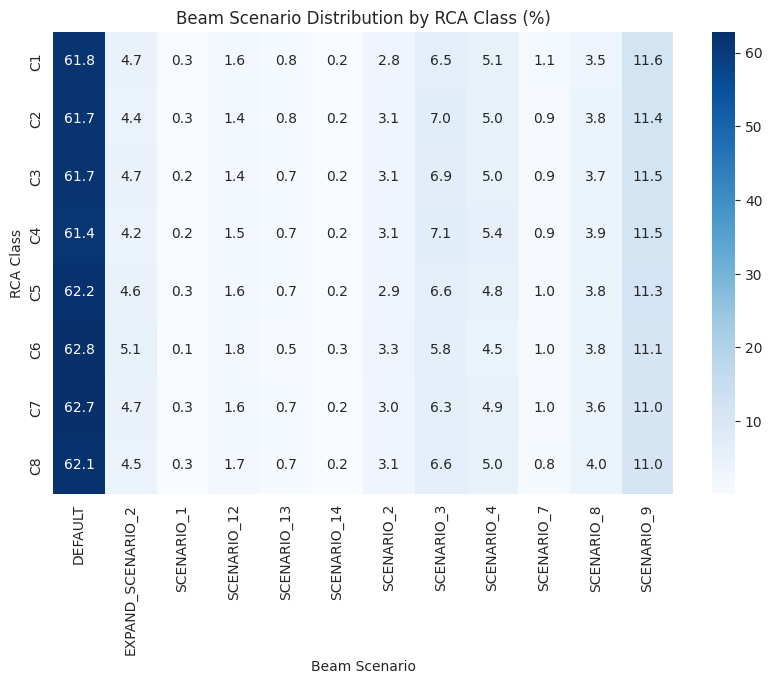

In [0]:
plt.figure(figsize=(10,6))

sns.heatmap(
    beam_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Beam Scenario Distribution by RCA Class (%)")
plt.ylabel("RCA Class")
plt.show()

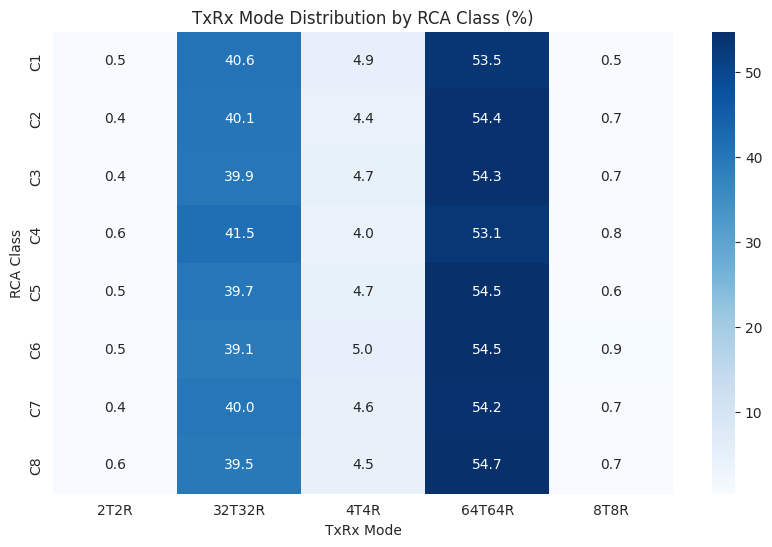

In [0]:
plt.figure(figsize=(10,6))

sns.heatmap(
    txrx_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues")

plt.title("TxRx Mode Distribution by RCA Class (%)")
plt.ylabel("RCA Class")
plt.show()

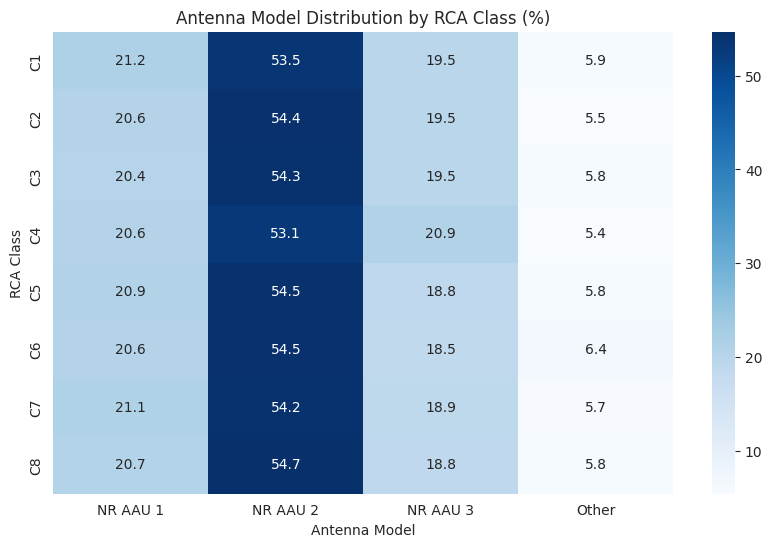

In [0]:
plt.figure(figsize=(10,6))

sns.heatmap(
    ant_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Antenna Model Distribution by RCA Class (%)")
plt.ylabel("RCA Class")
plt.show()

<Axes: xlabel='Antenna Model', ylabel='count'>

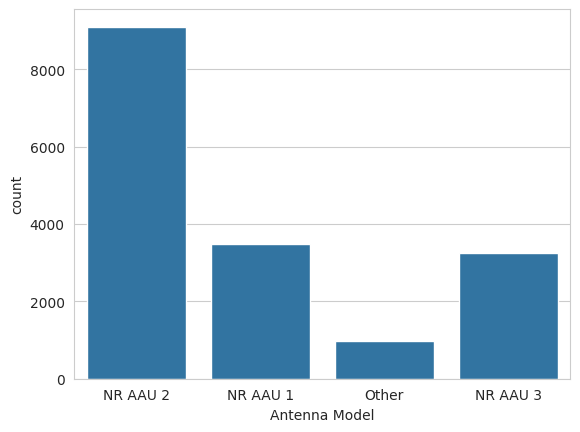

In [0]:
sns.countplot(
    data=engineer_inspect,
    x="Antenna Model"
)

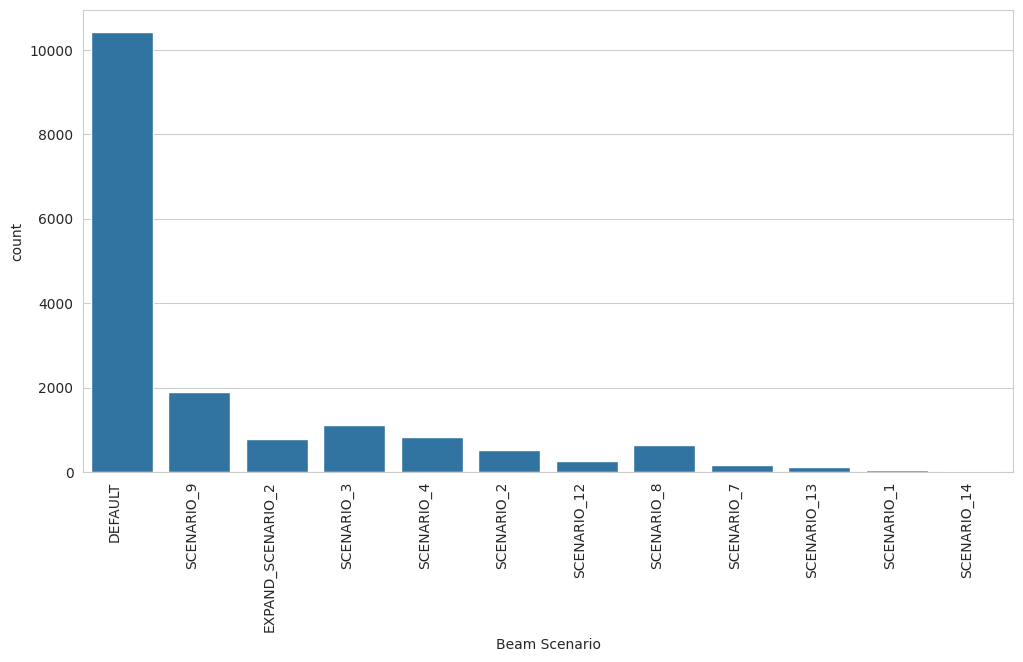

In [0]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=engineer_inspect,
    x="Beam Scenario"
)

plt.xticks(rotation=90, ha="right")
plt.show()

<Axes: xlabel='TxRx Mode', ylabel='count'>

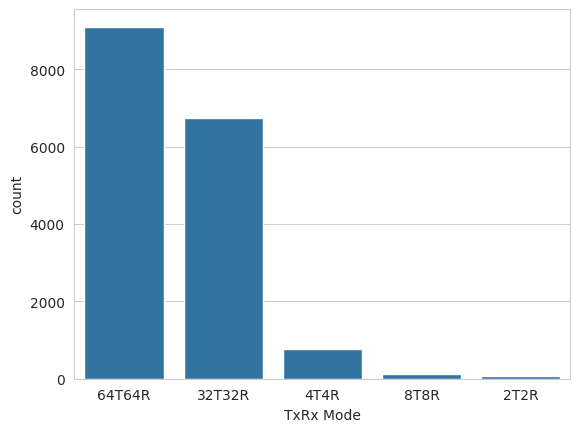

In [0]:
sns.countplot(
    data=engineer_inspect,
    x="TxRx Mode"
)

In [0]:
pd.crosstab(
    engineer_inspect["answer"],
    engineer_inspect["Antenna Model"],
    normalize="index"
)

Antenna Model,NR AAU 1,NR AAU 2,NR AAU 3,Other
answer,,,,
C1,0.211580,0.534632,0.194805,0.058983
C2,0.205922,0.544190,0.194706,0.055182
C3,0.204357,0.542919,0.194771,0.057952
C4,0.206048,0.531010,0.209124,0.053819
C5,0.209359,0.545381,0.187576,0.057685
C6,0.206030,0.544598,0.185302,0.064070
C7,0.211170,0.542193,0.189156,0.057481
C8,0.207249,0.547218,0.187851,0.057682


In [0]:
#Arrange Class Order
class_order = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']

In [0]:
#Set Colors
class_colors = {
    'C1': '#6EC6FF',  # light blue
    'C2': '#4B9CD3',  # medium-light blue
    'C3': '#00A8E0',  # sky blue
    'C4': '#009FDB',  # bright blue
    'C5': '#00B5AD',  # teal 
    'C6': '#0066B3',  # deep blue
    'C7': '#0057B8',  # darker blue
    'C8': '#004B87'   # navy
}

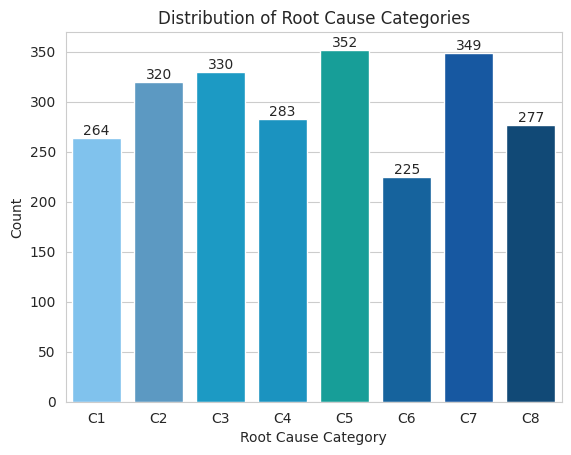

In [0]:
#Distribution of Root Cause Counts by Categories
ax = sns.countplot(data=telecom, x='answer', order=class_order, palette=class_colors, legend= False)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Root Cause Categories')
plt.xlabel('Root Cause Category')
plt.ylabel('Count')
plt.show()

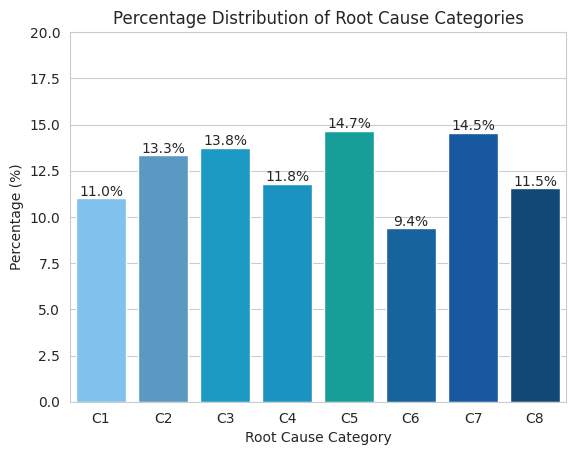

In [0]:
# Calculate Percentages
percent_df = (telecom['answer'].value_counts(normalize=True).mul(100).reset_index())
percent_df.columns = ['answer', 'percent']

# Plot Percent Bar Graph and Include Titles
ax = sns.barplot(data=percent_df, x='answer', y='percent', order=class_order, palette=class_colors, legend= False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
    
plt.title('Percentage Distribution of Root Cause Categories')
plt.xlabel('Root Cause Category')
plt.ylabel('Percentage (%)')
plt.ylim(0, 20)
plt.show()

In [0]:

#Check Row 0
parsed_df = telecom_structured.copy()
parsed_df.head(1)

question  ...                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           engineering
0  Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average scheduled RBs are below 160, affecting throughput.\n\nGiven:\n- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the actual downtilt angle in degrees.\n\nBeam Scenario and Vertical Beamwidth Relationships:\n- When the cell's Beam Scenario is set to Default or SCENARIO_1 to SCENARIO_5, the vertical beamwidth is 6 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_6 to SCENARIO_11, the vertical beamwidth is 12 degrees.\n- When the cell's Beam Scenario is set to SCENARIO_12 or above, the vertical beamwidth is 25 degrees.\n\nUser plane drive test data as follows：\n\nTimestamp|Longitude|Latitude|GPS Speed (km/h)|5G KPI PCell RF Serving PCI|5G KPI PCell RF Serving SS-RSRP [dBm]|5G KPI PCell RF Serving SS-SINR [dB]|5G KPI PCell Layer2 MAC DL Throughput [Mbps]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]|Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]|5G KPI PCell Layer1 DL RB Num (Including 0)\n2025-05-07 15:23:52.000000|128.188169|32.579273|1|712|-77.0|15.93|1351.25|258|71|284|-|-|-90.49|-95.82|-102.2|-|-|210.91\n2025-05-07 15:23:53.000000|128.18814|32.579223|2|71|-80.97|6.6|366.57|258|712|129|-|-|-88.72|-93.26|-105.47|-|-|211.23\n2025-05-07 15:23:54.000000|128.188117|32.579174|16|71|-85.5|1.81|334.0|258|712|-|-|-|-84.41|-96.46|-|-|-|210.99\n2025-05-07 15:23:55.000000|128.188103|32.579113|14|71|-88.21|5.4|431.94|712|258|-|-|-|-88.04|-93.72|-|-|-|195.26\n2025-05-07 15:23:56.000000|128.188088|32.579075|19|71|-78.45|13.59|566.34|712|258|284|-|-|-87.97|-98.7|-105.92|-|-|209.0\n2025-05-07 15:23:57.000000|128.188073|32.579033|22|258|-77.45|11.45|1308.74|712|71|284|129|-|-89.56|-93.31|-104.18|-110.78|-|204.95\n2025-05-07 15:23:58.000000|128.188051|32.579002|16|258|-81.66|10.06|1310.14|712|71|284|129|-|-84.85|-93.3|-102.87|-114.09|-|210.13\n2025-05-07 15:23:59.000000|128.188073|32.578995|26|258|-79.13|16.32|1023.36|712|71|284|129|-|-86.75|-93.71|-104.01|-107.26|-|208.06\n2025-05-07 15:24:00.000000|

#Check Row 0

In [0]:
parsed_df.loc[0, "question"]

"Analyze the 5G wireless network drive-test user plane data and engineering parameters.\nIdentify the reason for the throughput dropping below 600Mbps in certain road sections.\nFrom the following 8 potential root causes, select the most likely one and enclose its number in \\boxed{{}} in the final answer.\n\nC1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.\nC2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.\nC3: A neighboring cell provides higher throughput.\nC4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.\nC5: Frequent handovers degrade performance.\nC6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.\nC7: Test vehicle speed exceeds 40km/h, impacting user throughput.\nC8: Average scheduled RBs are below 160, affecting throughput.\n\nGiven:\n- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values 

In [0]:
parsed_df.loc[0, "answer"]

'C2'

In [0]:
parsed_df.loc[0, "drive_test"]

,Timestamp,Longitude,Latitude,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm],5G KPI PCell Layer1 DL RB Num (Including 0)
0,2025-05-07 15:23:52.000000,128.188169,32.579273,1,712,-77.00,15.93,1351.25,258,71,284,-,-,-90.49,-95.82,-102.2,-,-,210.91
1,2025-05-07 15:23:53.000000,128.188140,32.579223,2,71,-80.97,6.60,366.57,258,712,129,-,-,-88.72,-93.26,-105.47,-,-,211.23
2,2025-05-07 15:23:54.000000,128.188117,32.579174,16,71,-85.50,1.81,334.00,258,712,-,-,-,-84.41,-96.46,-,-,-,210.99
3,2025-05-07 15:23:55.000000,128.188103,32.579113,14,71,-88.21,5.40,431.94,712,258,-,-,-,-88.04,-93.72,-,-,-,195.26
4,2025-05-07 15:23:56.000000,128.188088,32.579075,19,71,-78.45,13.59,566.34,712,258,284,-,-,-87.97,-98.70,-105.92,-,-,209.00
5,2025-05-07 15:23:57.000000,128.188073,32.579033,22,258,-77.45,11.45,1308.74,712,71,284,129,-,-89.56,-93.31,-104.18,-110.78,-,204.95
6,2025-05-07 15:23:58.000000,128.188051,32.579002,16,258,-81.66,10.06,1310.14,712,71,284,129,-,-84.85,-93.30,-102.87,-114.09,-,210.13
7,2025-05-07 15:23:59.000000,128.188073,32.578995,26,258,-79.13,16.32,1023.36,712,71,284,129,-,-86.75,-93.71,-104.01,-107.26,-,208.06
8,2025-05-07 15:24:00.000000,128.188036,32.578984,33,258,-74.09,19.80,770.83,712,71,284,129,-,-89.29,-96.40,-100.21,-114.11,-,207.07
9,2025-05-07 15:24:01.000000,128.188036,32.578984,25,258,-71.09,19.62,1014.75,712,71,-,-,-,-90.14,-92.93,-,-,-,205.57


In [0]:
parsed_df.loc[0,"engineering"]

,gNodeB ID,Cell ID,Longitude,Latitude,Mechanical Azimuth,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model
0,34038,4,128.188273,32.579129,50,6,4,0,DEFAULT,5.0,712,64T64R,34.9,NR AAU 2
1,33164,27,128.217634,32.580720,240,3,10,0,DEFAULT,29.7,71,32T32R,34.9,NR AAU 1
2,34038,2,128.188282,32.579099,140,10,4,0,DEFAULT,5.0,258,64T64R,34.9,NR AAU 2
3,34038,24,128.187690,32.577910,40,44,9,10,SCENARIO_9,56.0,284,64T64R,34.9,NR AAU 2
4,33164,14,128.189481,32.581043,150,20,255,0,DEFAULT,28.7,129,64T64R,34.9,NR AAU 2


#EDA Row Count Analysis

In [0]:
import re

def extract_row_count(text):
    text = str(text)
    match = re.search(r"\[(\d+)\s+rows?\s+x\s+\d+\s+columns?\]", text)
    if match:
        return int(match.group(1))
    return None

parsed_df["drive_test_rows"] = parsed_df["drive_test"].apply(extract_row_count)
parsed_df["engineering_rows"] = parsed_df["engineering"].apply(extract_row_count)


parsed_df[["drive_test_rows","engineering_rows"]].head()
parsed_df[["drive_test_rows", "engineering_rows"]].describe()

,drive_test_rows,engineering_rows
count,2400.0,2400.000000
mean,10.0,7.002500
std,0.0,1.936463
min,10.0,4.000000
25%,10.0,6.000000
50%,10.0,7.000000
75%,10.0,8.000000
max,10.0,14.000000


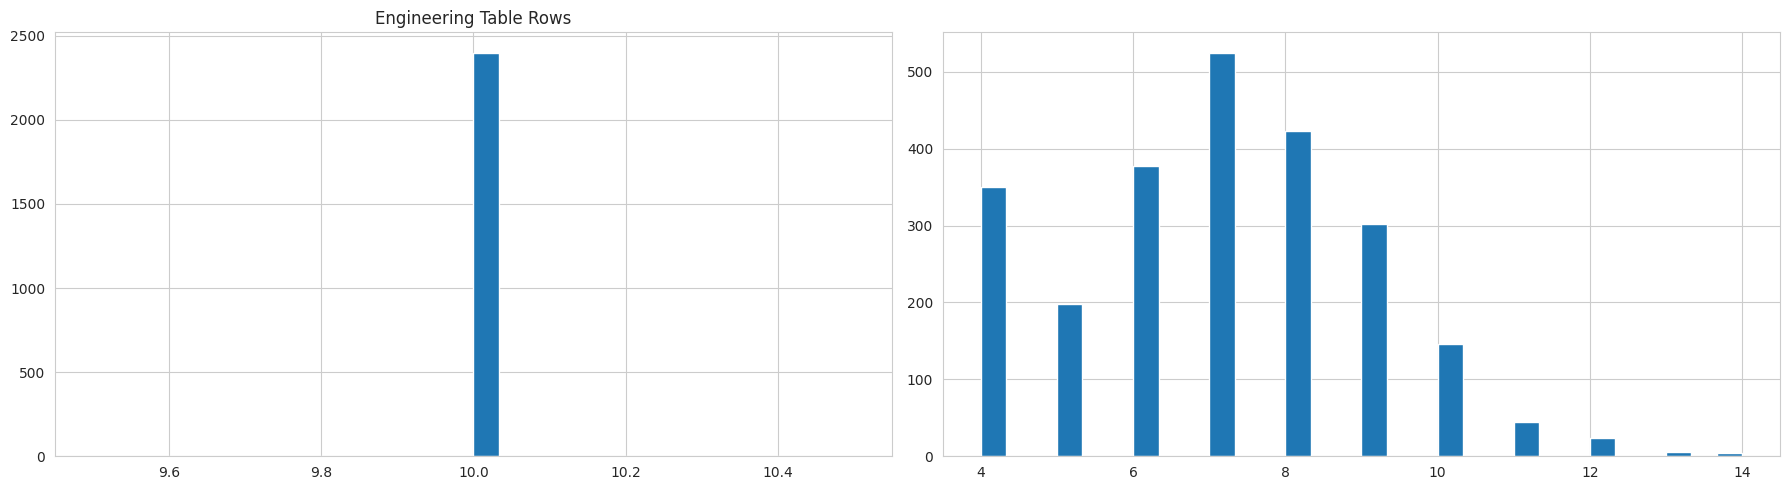

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

parsed_df["drive_test_rows"].hist(bins=30, ax=axes[0])
axes[0].set_title("Drive Test Table Rows")

parsed_df["engineering_rows"].hist(bins=30, ax=axes[1])
axes[0].set_title("Engineering Table Rows")

plt.tight_layout()
plt.show()

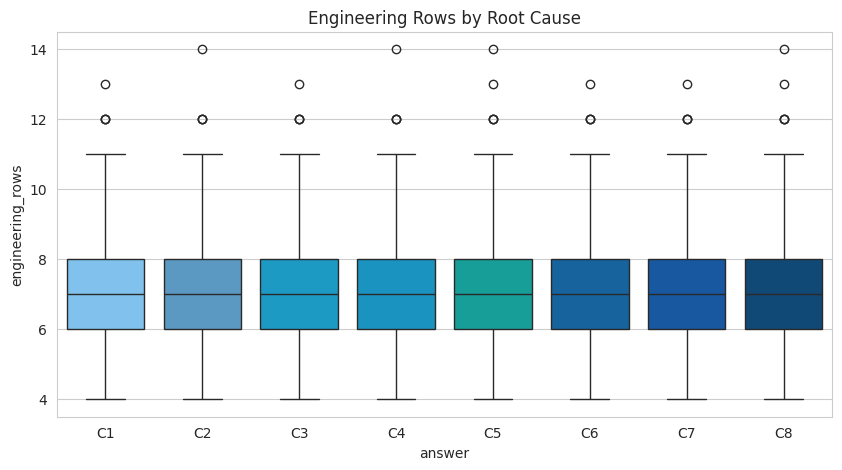

In [0]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=parsed_df,
    x="answer",
    y="engineering_rows",
    order=["C1","C2","C3","C4","C5","C6","C7","C8"],
    palette=class_colors
)

plt.title("Engineering Rows by Root Cause")
plt.show()

#EDA Length Analysis

In [0]:
parsed_df["question_length"] = parsed_df["question"].astype(str).str.len()
parsed_df["drive_test_length"] = parsed_df["drive_test"].astype(str).str.len()
parsed_df["engineering_length"] = parsed_df["engineering"].astype(str).str.len()

parsed_df[["question_length", "drive_test_length","engineering_length"]].head()
parsed_df[["question_length","drive_test_length", "engineering_length"]].describe()

,question_length,drive_test_length,engineering_length
count,2400.000000,2400.0,2400.000000
mean,4431.444167,903.0,702.721250
std,185.199781,0.0,165.784731
min,4078.000000,903.0,447.000000
25%,4309.000000,903.0,617.000000
50%,4432.000000,903.0,702.000000
75%,4556.250000,903.0,787.000000
max,4998.000000,903.0,1313.000000


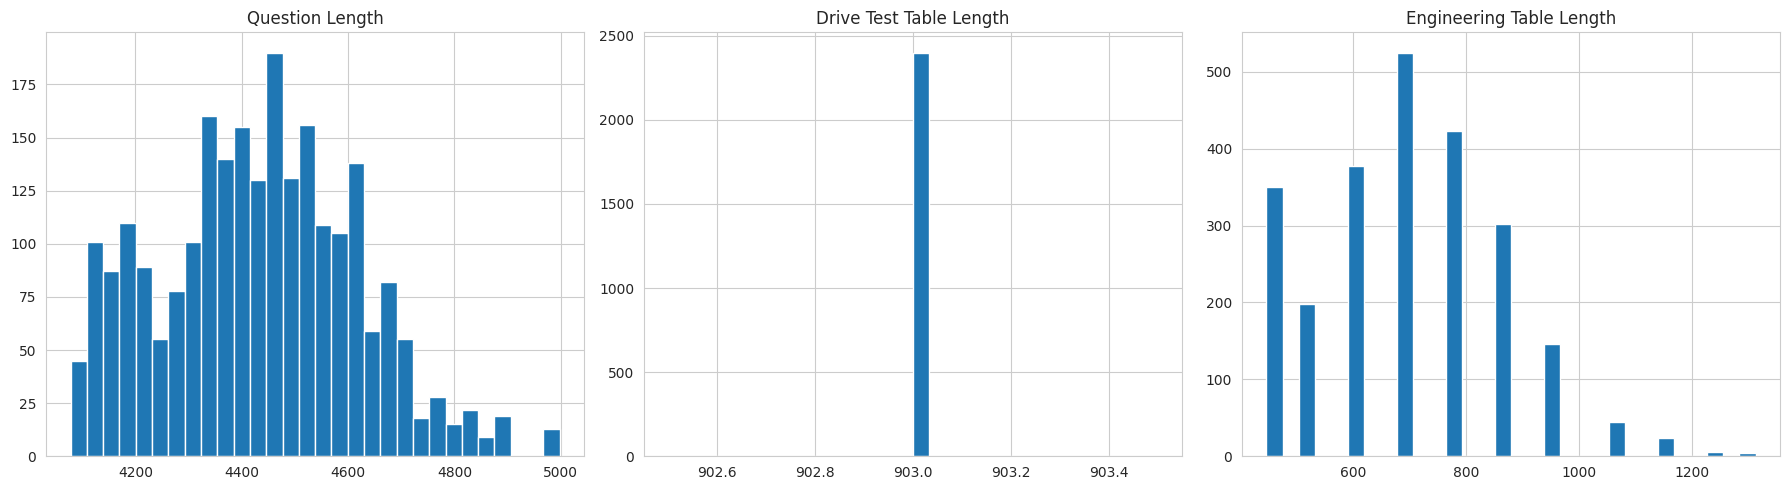

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

parsed_df["question_length"].hist(bins=30, ax=axes[0])
axes[0].set_title("Question Length")

parsed_df["drive_test_length"].hist(bins=30, ax=axes[1])
axes[1].set_title("Drive Test Table Length")

parsed_df["engineering_length"].hist(bins=30, ax=axes[2])
axes[2].set_title("Engineering Table Length")

plt.tight_layout()
plt.show()

#EDA Root Cause Category for Length

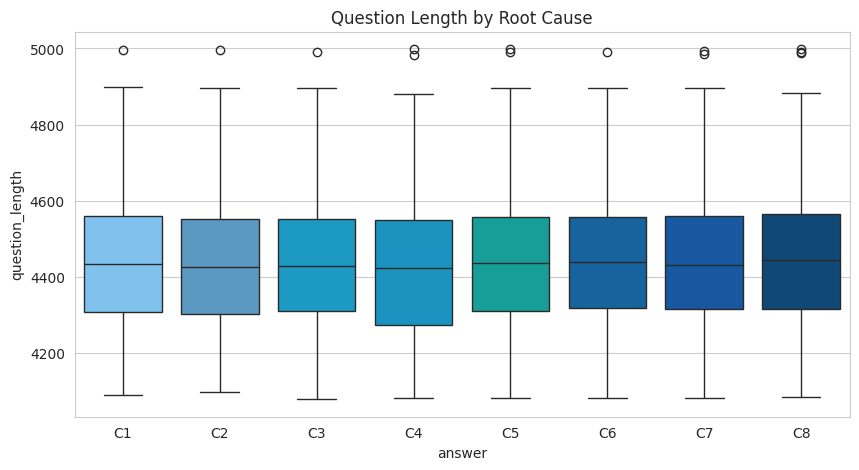

In [0]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=parsed_df, x="answer", y="question_length", palette=class_colors, order= class_order)

plt.title("Question Length by Root Cause")
plt.show()

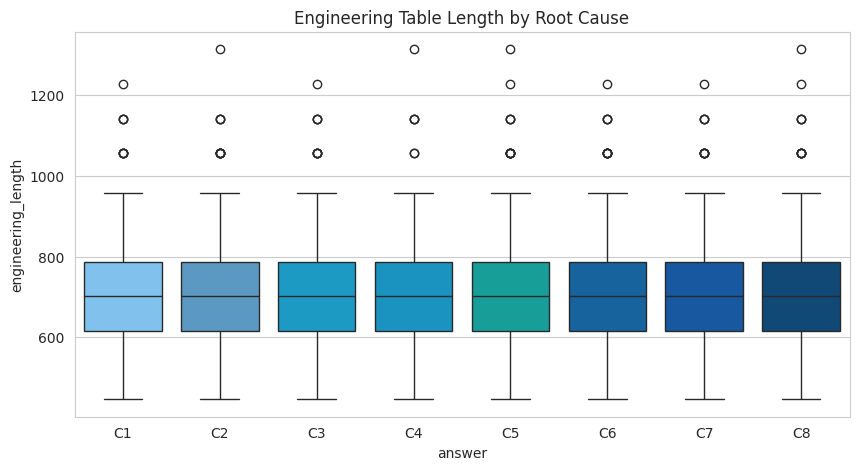

In [0]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=parsed_df, x="answer", y="engineering_length", palette=class_colors, order= class_order)
plt.title("Engineering Table Length by Root Cause")
plt.show()

In [0]:
print(parsed_df.loc[0, "drive_test"].columns.tolist())
print(parsed_df.loc[0, "engineering"].columns.tolist())

['Timestamp', 'Longitude', 'Latitude', 'GPS Speed (km/h)', '5G KPI PCell RF Serving PCI', '5G KPI PCell RF Serving SS-RSRP [dBm]', '5G KPI PCell RF Serving SS-SINR [dB]', '5G KPI PCell Layer2 MAC DL Throughput [Mbps]', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]', 'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]', '5G KPI PCell Layer1 DL RB Num 

In [0]:
type(parsed_df.loc[0, "drive_test"])

pandas.core.frame.DataFrame

In [0]:
#Calculate Mean
feature_rows = []

for idx, row in parsed_df.iterrows():

    dt = row["drive_test"]

    feature_rows.append({
        "answer": row["answer"],

        "avg_speed":
            dt["GPS Speed (km/h)"].mean(),

        "avg_rsrp":
            dt["5G KPI PCell RF Serving SS-RSRP [dBm]"].mean(),

        "avg_sinr":
            dt["5G KPI PCell RF Serving SS-SINR [dB]"].mean(),

        "avg_throughout":
            dt["5G KPI PCell Layer2 MAC DL Throughput [Mbps]"].mean(),

        "avg_rb":
            dt["5G KPI PCell Layer1 DL RB Num (Including 0)"].mean()
    })

features_df = pd.DataFrame(feature_rows)

In [0]:
features_df.head(5)

,answer,avg_speed,avg_rsrp,avg_sinr,avg_throughout,avg_rb
0,C2,17.4,-79.355,12.058,847.792,207.317
1,C1,18.5,-83.542,11.217,850.051,208.430
2,C2,18.9,-86.614,21.240,671.739,204.145
3,C2,15.8,-84.998,10.698,921.430,207.860
4,C5,21.4,-78.516,10.008,789.406,195.452


In [0]:
#Description of Averages
features_df.describe()

,avg_speed,avg_rsrp,avg_sinr,avg_throughout,avg_rb
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,21.855458,-82.797245,12.023711,745.287242,199.728436
std,6.652240,3.686962,6.474850,145.157304,13.902324
min,7.200000,-91.014000,-2.708000,504.807000,145.905500
25%,17.500000,-85.471000,7.411000,640.596000,199.943000
50%,20.200000,-83.384000,10.668000,711.197000,204.602000
75%,23.700000,-80.788000,17.023000,819.266000,207.529250
max,43.600000,-63.199000,29.774000,1197.858000,211.318000


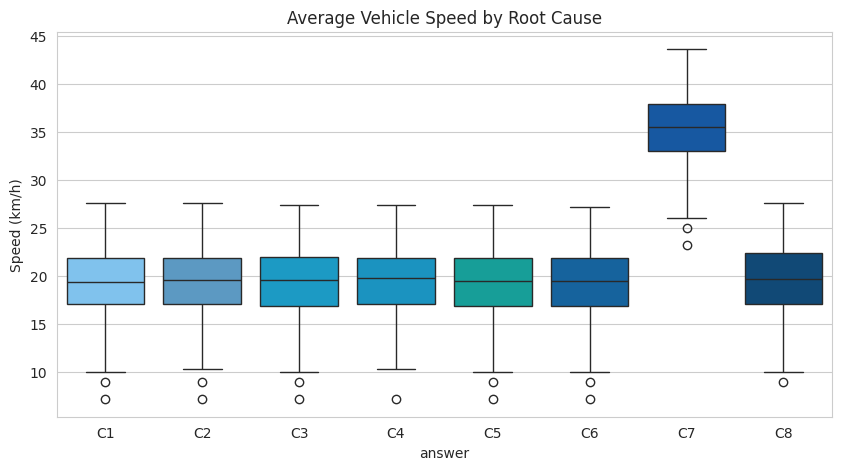

In [0]:
#Boxplot: Average Vehicle Speed by Root Cause
plt.figure(figsize=(10,5))

sns.boxplot(
    data=features_df,
    x="answer",
    y="avg_speed",
    order=class_order,
    palette=class_colors
)

plt.title("Average Vehicle Speed by Root Cause")
plt.ylabel("Speed (km/h)")
plt.show()

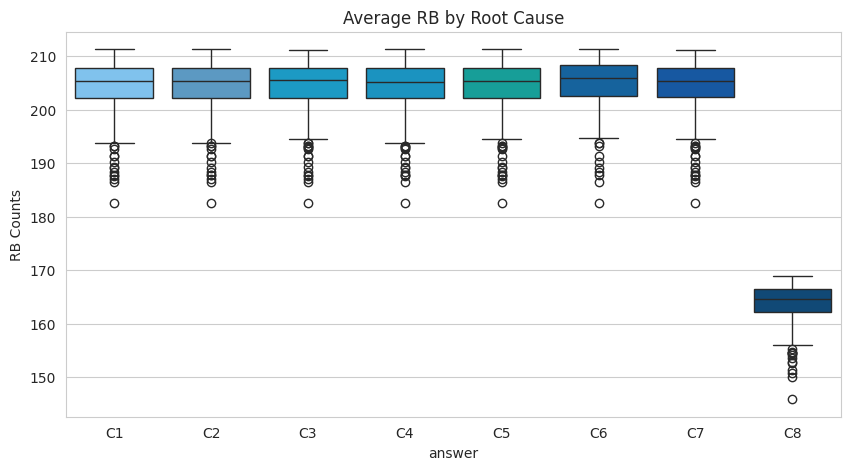

In [0]:
#Average RB by Root Cause
plt.figure(figsize=(10,5))

sns.boxplot(
    data=features_df,
    x="answer",
    y="avg_rb",
    order=class_order,
    palette=class_colors
)

plt.title("Average RB by Root Cause")
plt.ylabel("RB Counts")
plt.show()

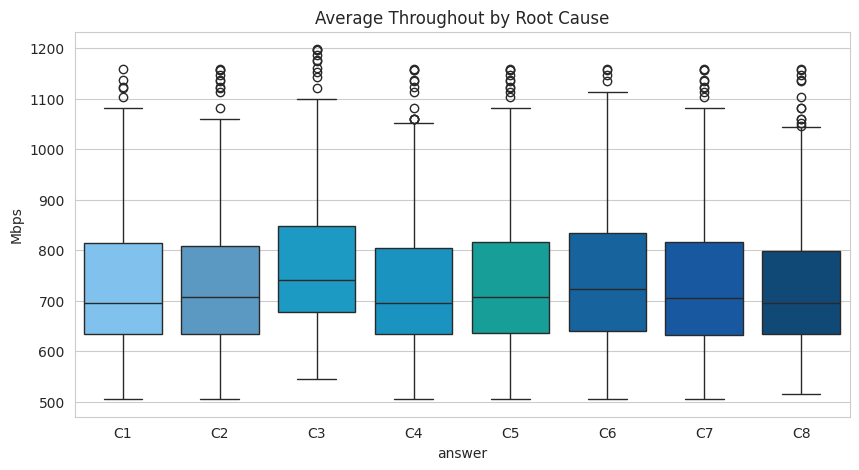

In [0]:
#Average Throughout by Root Cause
plt.figure(figsize=(10,5))

sns.boxplot(
    data=features_df,
    x="answer",
    y="avg_throughout",
    order=class_order,
    palette=class_colors
)

plt.title("Average Throughout by Root Cause")
plt.ylabel("Mbps")
plt.show()

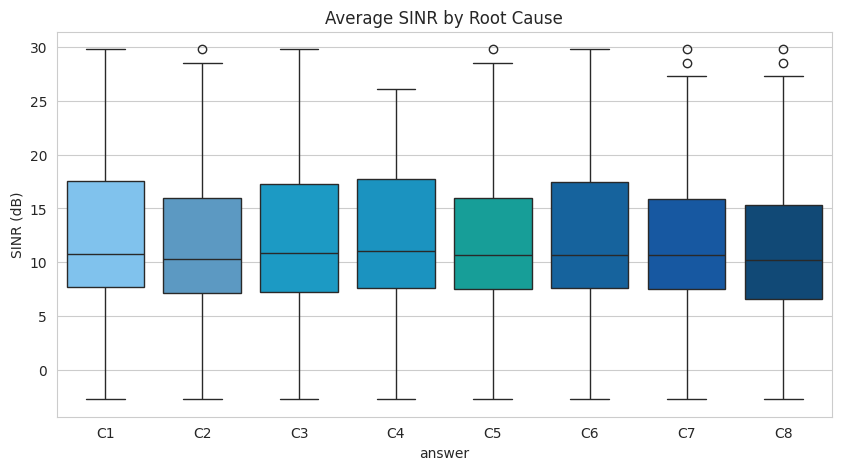

In [0]:
#Average SINR by Root Cause
plt.figure(figsize=(10,5))

sns.boxplot(
    data=features_df,
    x="answer",
    y="avg_sinr",
    order=class_order,
    palette=class_colors
)

plt.title("Average SINR by Root Cause")
plt.ylabel("SINR (dB)")
plt.show()

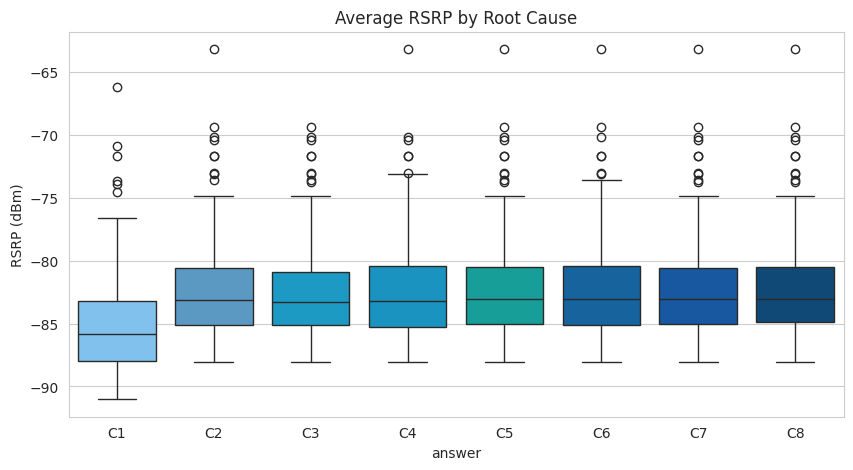

In [0]:
#Average RSPR by Root Cause
plt.figure(figsize=(10,5))

sns.boxplot(
    data=features_df,
    x="answer",
    y="avg_rsrp",
    order=class_order,
    palette=class_colors
)

plt.title("Average RSRP by Root Cause")
plt.ylabel("RSRP (dBm)")
plt.show()

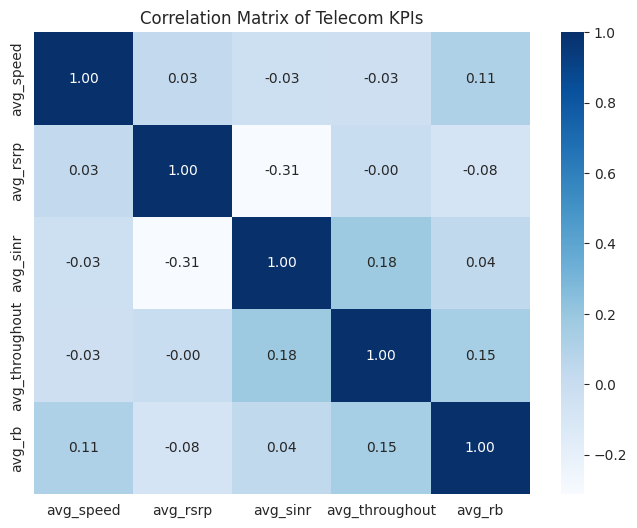

In [0]:
#Heat Map
corr_cols = [
    "avg_speed",
    "avg_rsrp",
    "avg_sinr",
    "avg_throughout",
    "avg_rb"
]

corr = features_df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix of Telecom KPIs")
plt.show()

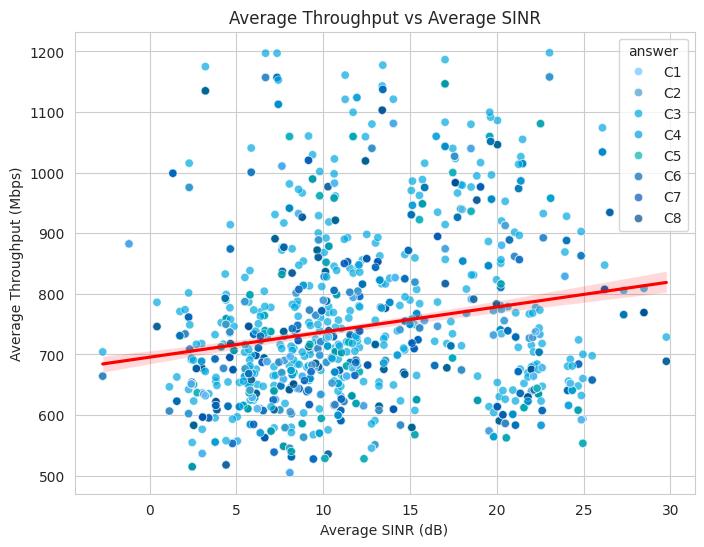

In [0]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=features_df,
    x="avg_sinr",
    y="avg_throughout",
    hue="answer",
    palette=class_colors,
    alpha=0.7,
    hue_order=class_order
    
)

sns.regplot(
    data=features_df,
    x="avg_sinr",
    y="avg_throughout",
    scatter=False,
    color="red"
)

plt.title("Average Throughput vs Average SINR")
plt.xlabel("Average SINR (dB)")
plt.ylabel("Average Throughput (Mbps)")
plt.show()